In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

In [2]:
Data_PSH = pd.read_csv("./PS-H_Standard.csv")
Data_PSL = pd.read_csv("./PS-L_Standard.csv")

# Plotting the Standards

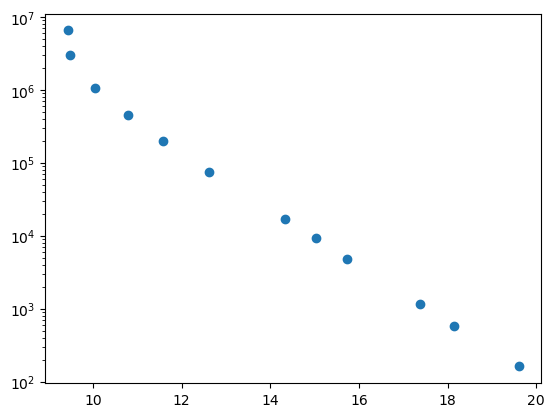

In [3]:
# PS-H
plt.scatter(Data_PSH.rv,Data_PSH.Mp)
plt.yscale('log')

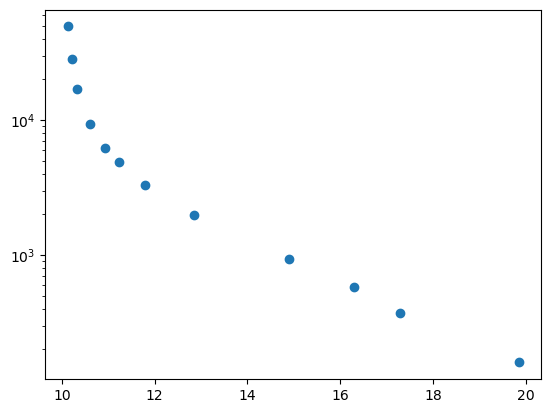

In [4]:
# PS-L
plt.scatter(Data_PSL.rv,Data_PSL.Mp)
plt.yscale('log')

# Fitting the Standards

(4.0, 28.0)

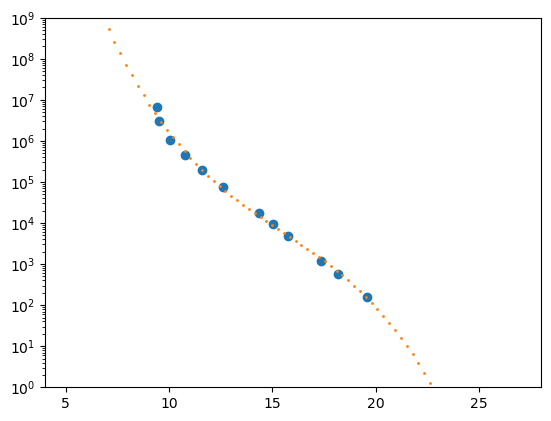

In [5]:
def ConvertPSH_rv_mp(RvValues):
    x = np.array(Data_PSH.rv)
    y = np.log(np.array(Data_PSH.Mp))
    # plt.scatter(x,y)

    coefficients = np.polyfit(x,y,3)
    p = np.poly1d(coefficients)
    xp = np.linspace(np.min(Data_PSH.rv),np.max(Data_PSH.rv),100)
    # plt.scatter(xp,p(xp))
    
    LoggedMpValues = p(RvValues)
    MpValues = np.exp(LoggedMpValues)
    return MpValues

PSHSomeRvValues = np.linspace(0,28,100)
PSHSomeMpValues = ConvertPSH_rv_mp(PSHSomeRvValues)

plt.scatter(Data_PSH.rv,Data_PSH.Mp)
plt.scatter(PSHSomeRvValues,PSHSomeMpValues,s=1)
plt.ylim(1,1000000000)
plt.yscale('log')
plt.xlim(4,28)

(4.0, 28.0)

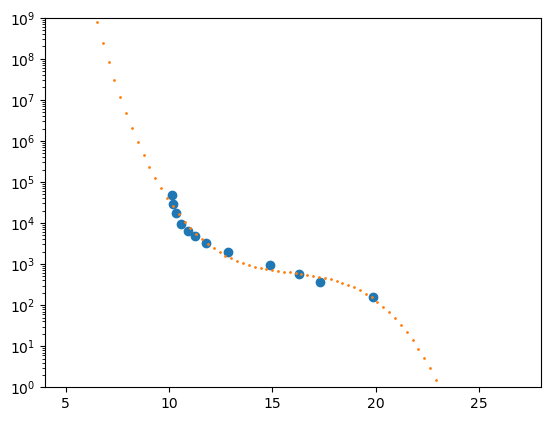

In [6]:
def ConvertPSL_rv_mp(RvValues):
    x = np.array(Data_PSL.rv)
    y = np.log(np.array(Data_PSL.Mp))
    coefficients = np.polyfit(x,y,3)
    p = np.poly1d(coefficients)
    xp = np.linspace(np.min(Data_PSL.rv),np.max(Data_PSL.rv),100)
    LoggedMpValues = p(RvValues)
    MpValues = np.exp(LoggedMpValues)
    return MpValues

PSLSomeRvValues = np.linspace(0,28,100)
PSLSomeMpValues = ConvertPSL_rv_mp(PSLSomeRvValues)

plt.scatter(Data_PSL.rv,Data_PSL.Mp)
plt.scatter(PSLSomeRvValues,PSLSomeMpValues,s=1)
plt.ylim(1,1000000000)
plt.yscale('log')
plt.xlim(4,28)

# Plotting Standard Overlays

In [7]:
Data_HMWR_PPI = pd.read_csv("./HMWR_PPI.csv")
Data_HMWR_PPSI = pd.read_csv("./HMWR_PPSI.csv")
Data_LMWR_PPI = pd.read_csv("./LMWR_PPI.csv")
Data_LMWR_PPSI = pd.read_csv("./LMWR_PPSI.csv")

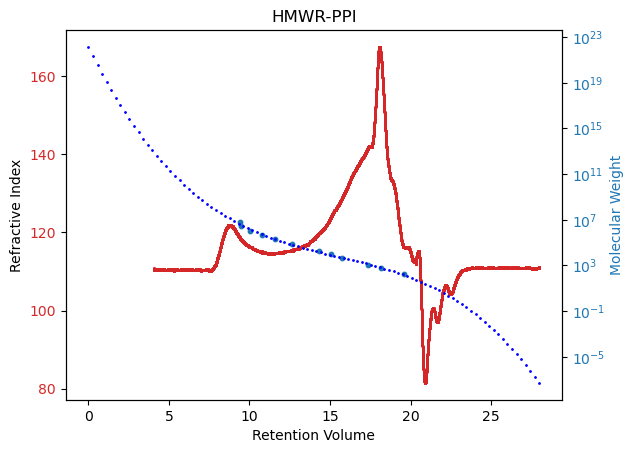

In [8]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPI")
color = 'tab:red'
ax1.set_ylabel("Refractive Index")
ax1.set_xlabel("Retention Volume")
ax1.scatter(Data_HMWR_PPI.rv,Data_HMWR_PPI.ri,color=color,s=1)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Molecular Weight',color=color)
ax2.scatter(Data_PSH.rv,Data_PSH.Mp,color=color,s=10)
ax2.scatter(PSHSomeRvValues,PSHSomeMpValues,color='blue',s=1)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')

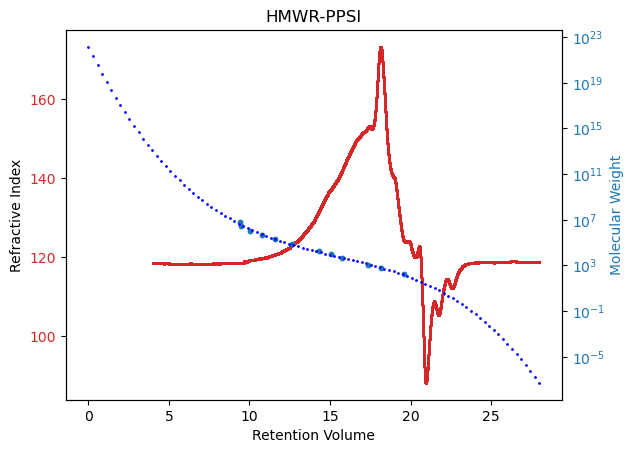

In [9]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPSI")
color = 'tab:red'
ax1.set_ylabel("Refractive Index")
ax1.set_xlabel("Retention Volume")
ax1.scatter(Data_HMWR_PPSI.rv,Data_HMWR_PPSI.ri,color=color,s=1)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Molecular Weight',color=color)
ax2.scatter(Data_PSH.rv,Data_PSH.Mp,color=color,s=10)
ax2.scatter(PSHSomeRvValues,PSHSomeMpValues,color='blue',s=1)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')

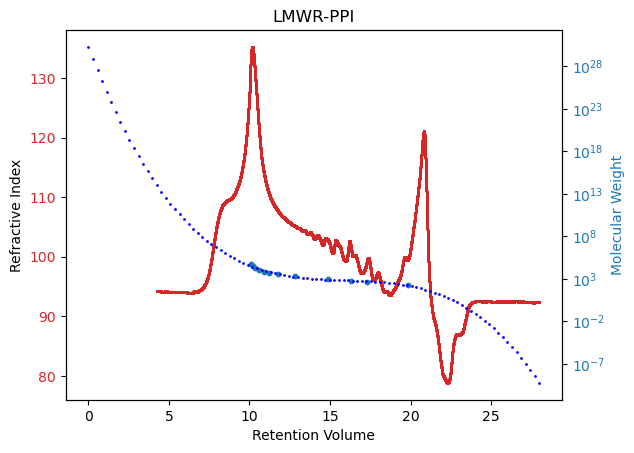

In [10]:
fig, ax1 = plt.subplots()
ax1.set_title("LMWR-PPI")
color = 'tab:red'
ax1.set_ylabel("Refractive Index")
ax1.set_xlabel("Retention Volume")
ax1.scatter(Data_LMWR_PPI.rv,Data_LMWR_PPI.ri,color=color,s=1)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Molecular Weight',color=color)
ax2.scatter(Data_PSL.rv,Data_PSL.Mp,color=color,s=10)
ax2.scatter(PSLSomeRvValues,PSLSomeMpValues,color='blue',s=1)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')

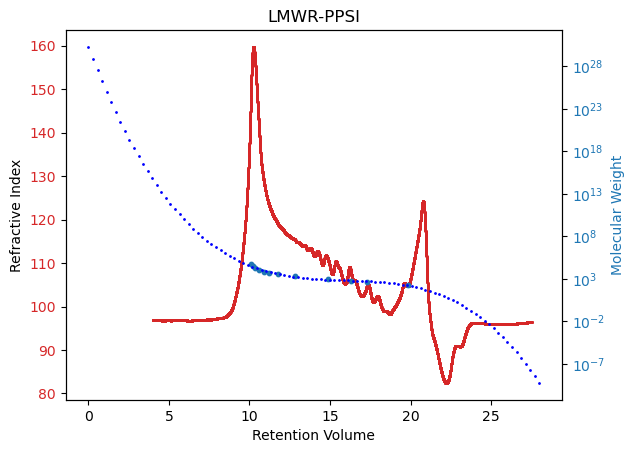

In [11]:
fig, ax1 = plt.subplots()
ax1.set_title("LMWR-PPSI")
color = 'tab:red'
ax1.set_ylabel("Refractive Index")
ax1.set_xlabel("Retention Volume")
ax1.scatter(Data_LMWR_PPSI.rv,Data_LMWR_PPSI.ri,color=color,s=1)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Molecular Weight',color=color)
ax2.scatter(Data_PSL.rv,Data_PSL.Mp,color=color,s=10)
ax2.scatter(PSLSomeRvValues,PSLSomeMpValues,color='blue',s=1)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')

# Basic Cut-Offs

In [12]:
def AnXAxisCutter(LowerLimit,UpperLimit,Dataframe):
    StartIdx = 0
    EndIdx = len(Dataframe)-1
    LowerLimitIdx = 0
    UpperLimitIdx = 0
    for count,i in enumerate(Dataframe.rv):
        if i > LowerLimit:
            LowerLimitIdx = count
            break
    for count,i in enumerate(Dataframe.rv):
        if i > UpperLimit:
            UpperLimitIdx = count
            break
    FirstDropRange = np.linspace(StartIdx,LowerLimitIdx,(LowerLimitIdx-StartIdx)+1).astype(int).tolist()
    SecondDropRange = np.linspace(UpperLimitIdx,EndIdx,(EndIdx-UpperLimitIdx)+1).astype(int).tolist()
    NewDataframe = Dataframe.drop(FirstDropRange)
    NewestDataframe = NewDataframe.drop(SecondDropRange)
    return NewestDataframe

In [13]:
Data_HMWR_PPI_CutOff = AnXAxisCutter(7.6,20.2,Data_HMWR_PPI)
Data_HMWR_PPSI_CutOff = AnXAxisCutter(9.4,20.4,Data_HMWR_PPSI)
Data_LMWR_PPI_CutOff = AnXAxisCutter(6.5,18.8,Data_LMWR_PPI)
Data_LMWR_PPSI_CutOff = AnXAxisCutter(7.7,18.8,Data_LMWR_PPSI)

# Conversion of X Axes

In [14]:
Data_HMWR_PPI_rv = np.array(Data_HMWR_PPI_CutOff.rv).tolist()
Data_HMWR_PPSI_rv = np.array(Data_HMWR_PPSI_CutOff.rv).tolist()
Data_LMWR_PPI_rv = np.array(Data_LMWR_PPI_CutOff.rv).tolist()
Data_LMWR_PPSI_rv = np.array(Data_LMWR_PPSI_CutOff.rv).tolist()

In [15]:
Data_HMWR_PPI_mp = list(reversed(ConvertPSH_rv_mp(Data_HMWR_PPI_CutOff.rv)))
Data_HMWR_PPSI_mp = list(reversed(ConvertPSH_rv_mp(Data_HMWR_PPSI_CutOff.rv)))
Data_LMWR_PPI_mp = list(reversed(ConvertPSL_rv_mp(Data_LMWR_PPI_CutOff.rv)))
Data_LMWR_PPSI_mp = list(reversed(ConvertPSL_rv_mp(Data_LMWR_PPSI_CutOff.rv)))

In [16]:
Data_HMWR_PPI_ri_init = list(reversed(np.array(Data_HMWR_PPI_CutOff.ri).tolist()))
Data_HMWR_PPSI_ri_init = list(reversed(np.array(Data_HMWR_PPSI_CutOff.ri).tolist()))
Data_LMWR_PPI_ri_init = list(reversed(np.array(Data_LMWR_PPI_CutOff.ri).tolist()))
Data_LMWR_PPSI_ri_init = list(reversed(np.array(Data_LMWR_PPSI_CutOff.ri).tolist()))

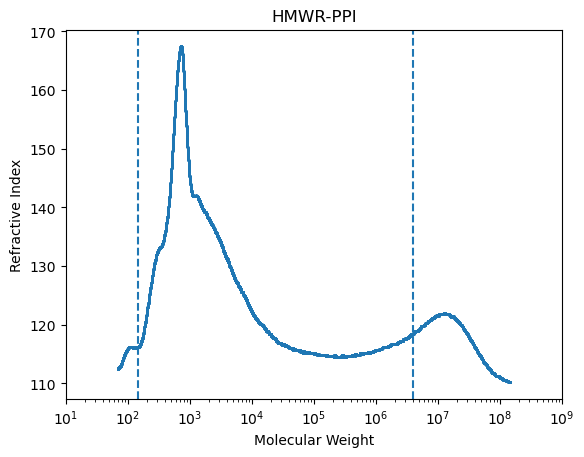

In [17]:
plt.title("HMWR-PPI")
plt.scatter(Data_HMWR_PPI_mp,Data_HMWR_PPI_ri_init,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.show()

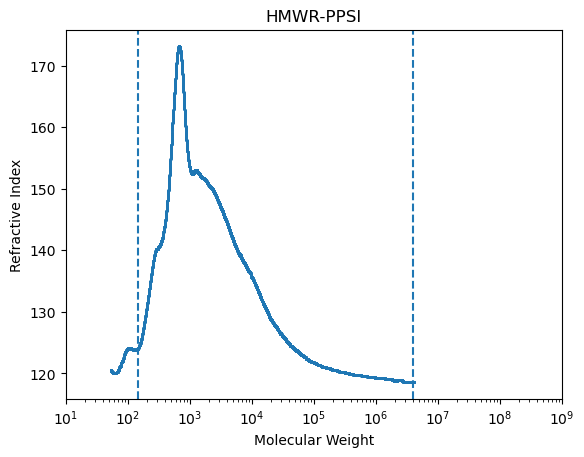

In [18]:
plt.title("HMWR-PPSI")
plt.scatter(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_ri_init,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.show()

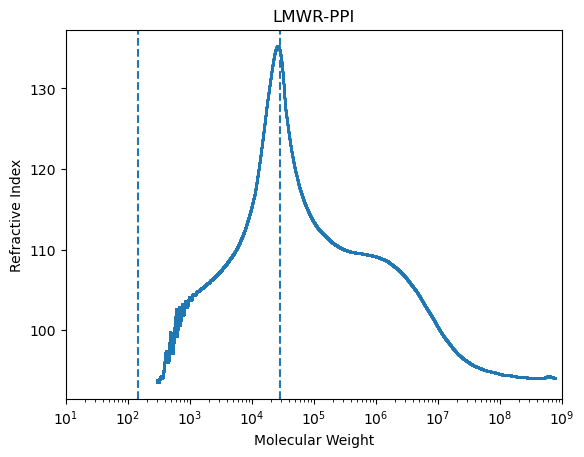

In [19]:
plt.title("LMWR-PPI")
plt.scatter(Data_LMWR_PPI_mp,Data_LMWR_PPI_ri_init,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.min(Data_PSL.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.max(Data_PSL.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.show()

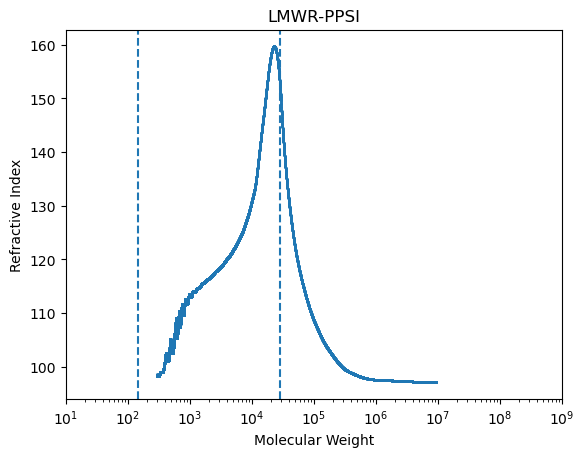

In [20]:
plt.title("LMWR-PPSI")
plt.scatter(Data_LMWR_PPSI_mp,Data_LMWR_PPSI_ri_init,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.min(Data_PSL.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.max(Data_PSL.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.show()

# Baseline Corrected Y Axes

In [21]:
Baseline_HMWR_PPI = np.array(Data_HMWR_PPI_ri_init)[-1]
Baseline_HMWR_PPSI = np.array(Data_HMWR_PPSI_ri_init)[-1]
Baseline_LMWR_PPI = np.array(Data_LMWR_PPI_ri_init)[-1]
Baseline_LMWR_PPSI = np.array(Data_LMWR_PPSI_ri_init)[-1]

In [22]:
def RemoveBaseline(Baseline,RawData):
    ProcessedData = []
    for i in RawData:
        j = i-Baseline
        if j < 0:
            ProcessedDatum = 0
            ProcessedData.append(ProcessedDatum)
        else:
            ProcessedDatum = j
            ProcessedData.append(ProcessedDatum)
    return ProcessedData

In [23]:
Data_HMWR_PPI_ri = RemoveBaseline(Baseline_HMWR_PPI,Data_HMWR_PPI_ri_init)
Data_HMWR_PPSI_ri = RemoveBaseline(Baseline_HMWR_PPSI,Data_HMWR_PPSI_ri_init)
Data_LMWR_PPI_ri = RemoveBaseline(Baseline_LMWR_PPI,Data_LMWR_PPI_ri_init)
Data_LMWR_PPSI_ri = RemoveBaseline(Baseline_LMWR_PPSI,Data_LMWR_PPSI_ri_init)

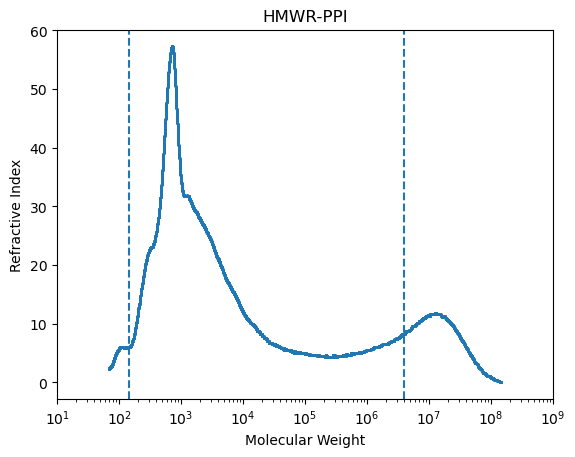

In [24]:
plt.title("HMWR-PPI")
plt.scatter(Data_HMWR_PPI_mp,Data_HMWR_PPI_ri,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.show()

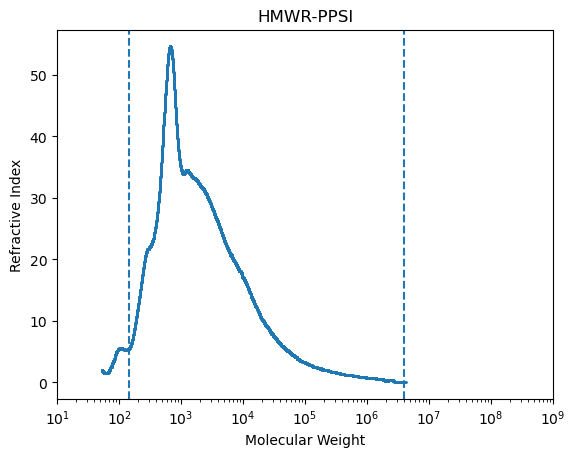

In [25]:
plt.title("HMWR-PPSI")
plt.scatter(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_ri,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.show()

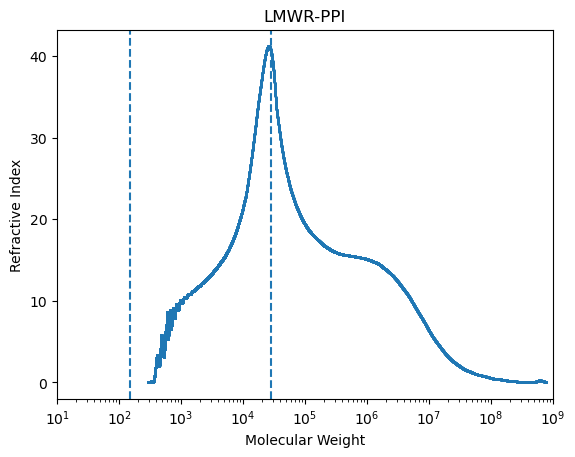

In [26]:
plt.title("LMWR-PPI")
plt.scatter(Data_LMWR_PPI_mp,Data_LMWR_PPI_ri,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.min(Data_PSL.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.max(Data_PSL.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.show()

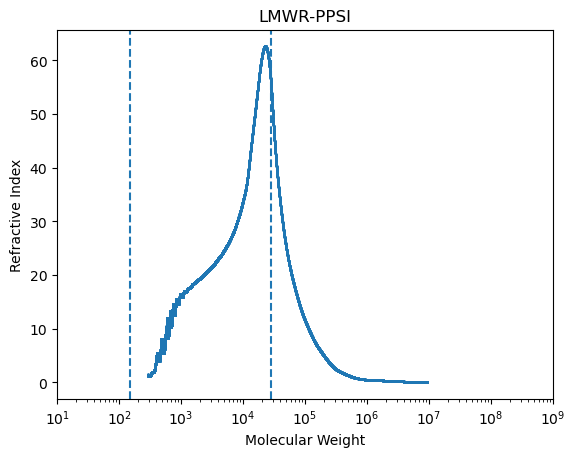

In [27]:
plt.title("LMWR-PPSI")
plt.scatter(Data_LMWR_PPSI_mp,Data_LMWR_PPSI_ri,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.min(Data_PSL.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.max(Data_PSL.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.show()

# Weight Fraction & Differential Distribution Y Axes

In [28]:
def TotalAreaFinder(MolecularWeightVals,RefractiveIndexVals):
    LasMolWeiVal = MolecularWeightVals[0]
    LasRefIndVal = RefractiveIndexVals[0]
    Areas = []
    for count,(MolWeiVal,RefIndVal) in enumerate(zip(MolecularWeightVals,RefractiveIndexVals)):
        if count == 0:
            continue
        else:
            CurMolWeiVal = MolWeiVal
            DifMolWeiVal = abs(CurMolWeiVal-LasMolWeiVal)
            CurRefIndVal = RefIndVal
            DifRefIndVal = abs(CurRefIndVal-LasRefIndVal)
            LowestRefIndVal = np.min(np.array([CurRefIndVal,LasRefIndVal]))
            TriangularArea = (DifRefIndVal*DifMolWeiVal)/2
            SquareArea = DifMolWeiVal*LowestRefIndVal
            TotalArea = TriangularArea+SquareArea
            Areas.append(TotalArea)
            LasMolWeiVal = CurMolWeiVal
            LasRefIndVal = CurRefIndVal
            continue
    Area = np.sum(np.array(Areas))
    return Area

In [29]:
# Specific Areas
Area_HMWR_PPI = TotalAreaFinder(Data_HMWR_PPI_mp,Data_HMWR_PPI_ri)
Area_HMWR_PPSI = TotalAreaFinder(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_ri)
Area_LMWR_PPI = TotalAreaFinder(Data_LMWR_PPI_mp,Data_LMWR_PPI_ri)
Area_LMWR_PPSI = TotalAreaFinder(Data_LMWR_PPSI_mp,Data_LMWR_PPSI_ri)

In [30]:
# Unified Area (To allow inter-comparison!)
Area_HMWR_PPI = 100000
Area_HMWR_PPSI = 100000
Area_LMWR_PPI = 100000
Area_LMWR_PPSI = 100000

In [31]:
def WeightFractionAndDifferentialDistributionFinder(MolecularWeightVals,RefractiveIndexVals,TotRefIndArea):
    LasMolWeiVal = MolecularWeightVals[0]
    LasRefIndVal = RefractiveIndexVals[0]
    NewMolWeiVals = []
    NewWeiFraVals = []
    NewDifDisVals = []
    for count,(MolWeiVal,RefIndVal) in enumerate(zip(MolecularWeightVals,RefractiveIndexVals)):
        if count == 0:
            continue
        else:
            CurMolWeiVal = MolWeiVal
            DifMolWeiVal = abs(CurMolWeiVal-LasMolWeiVal)
            HalDifMolWeiVal = DifMolWeiVal/2
            NewMolWeiVal = CurMolWeiVal+HalDifMolWeiVal
            NewMolWeiVals.append(NewMolWeiVal)
            
            CurRefIndVal = RefIndVal
            DifRefIndVal = abs(CurRefIndVal-LasRefIndVal)
            HalDifRefIndVal = DifRefIndVal/2
            LowestRefIndVal = np.min(np.array([CurRefIndVal,LasRefIndVal]))
            NewRefIndVal = LowestRefIndVal+HalDifRefIndVal

            NewWeiFraVal = NewRefIndVal/TotRefIndArea
            NewWeiFraVals.append(NewWeiFraVal)

            LogDifMolWeiVal = np.log(CurMolWeiVal)-np.log(LasMolWeiVal)
            NewDifDisVal = NewWeiFraVal/LogDifMolWeiVal
            NewDifDisVals.append(NewDifDisVal)
            
            LasMolWeiVal = CurMolWeiVal
            LasRefIndVal = CurRefIndVal
            continue
    return NewMolWeiVals,NewWeiFraVals,NewDifDisVals

In [ ]:
Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_wf_Mod,Data_HMWR_PPI_dd_Mod = WeightFractionAndDifferentialDistributionFinder(Data_HMWR_PPI_mp,Data_HMWR_PPI_ri,Area_HMWR_PPI)
Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_wf_Mod,Data_HMWR_PPSI_dd_Mod = WeightFractionAndDifferentialDistributionFinder(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_ri,Area_HMWR_PPSI)
Data_LMWR_PPI_mp_Mod,Data_LMWR_PPI_wf_Mod,Data_LMWR_PPI_dd_Mod = WeightFractionAndDifferentialDistributionFinder(Data_LMWR_PPI_mp,Data_LMWR_PPI_ri,Area_LMWR_PPI)
Data_LMWR_PPSI_mp_Mod,Data_LMWR_PPSI_wf_Mod,Data_LMWR_PPSI_dd_Mod = WeightFractionAndDifferentialDistributionFinder(Data_LMWR_PPSI_mp,Data_LMWR_PPSI_ri,Area_LMWR_PPSI)

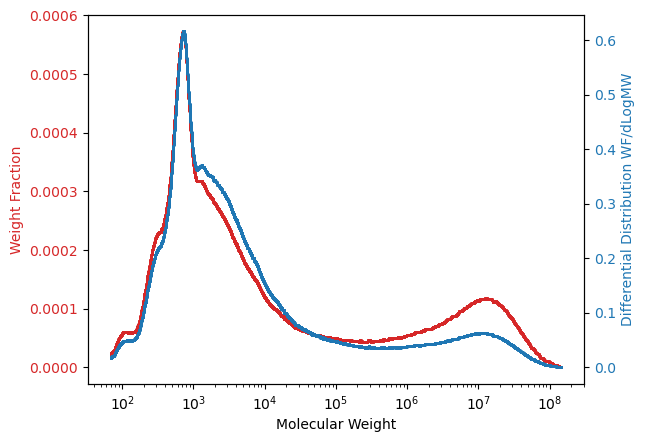

In [33]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_ylabel('Weight Fraction',color=color)
ax1.set_xlabel('Molecular Weight')
ax1.scatter(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_wf_Mod,s=1,label="PPI",color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Differential Distribution WF/dLogMW',color=color)
ax2.scatter(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_dd_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

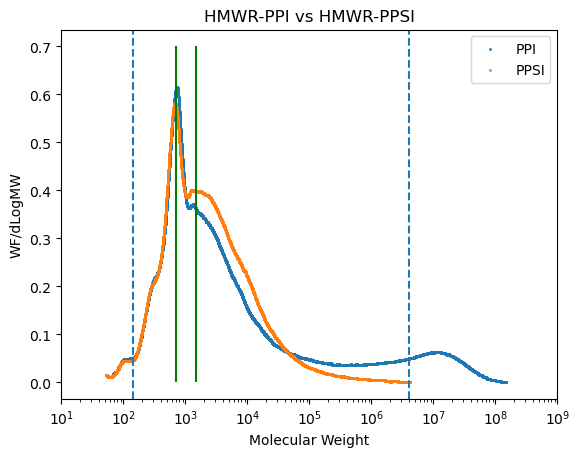

In [34]:
# plt.subplots(figsize=(10, 5))
plt.title("HMWR-PPI vs HMWR-PPSI")
plt.scatter(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_dd_Mod,s=1,label="PPI")
plt.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_dd_Mod,s=1,label="PPSI")
plt.xlabel("Molecular Weight")
plt.ylabel("WF/dLogMW")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
# plt.ylim(0,7)
plt.legend()

plt.vlines(ymin=0,ymax=0.7,x=700,color="green")
plt.vlines(ymin=0,ymax=0.7,x=1500,color="green")
plt.show()


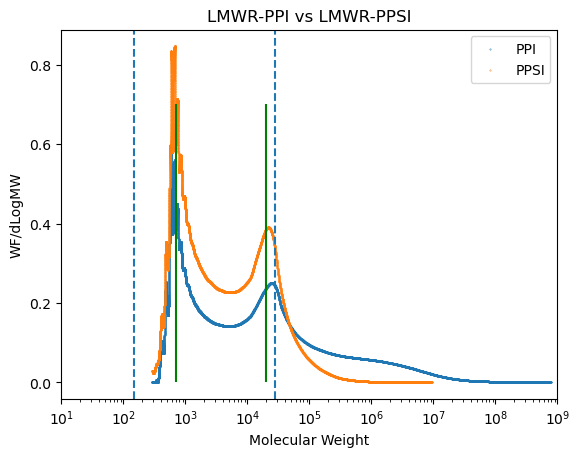

In [35]:
# plt.subplots(figsize=(10, 5))
plt.title("LMWR-PPI vs LMWR-PPSI")
plt.scatter(Data_LMWR_PPI_mp_Mod,Data_LMWR_PPI_dd_Mod,s=0.1,label="PPI")
plt.scatter(Data_LMWR_PPSI_mp_Mod,Data_LMWR_PPSI_dd_Mod,s=0.1,label="PPSI")
plt.xlabel("Molecular Weight")
plt.ylabel("WF/dLogMW")
plt.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.min(Data_PSL.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.max(Data_PSL.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
# plt.ylim(0,9)
plt.legend()
plt.vlines(ymin=0,ymax=0.7,x=700,color="green")
plt.vlines(ymin=0,ymax=0.7,x=20000,color="green")
plt.show()

# Cumulative Weight Fraction

In [57]:
def CumulativeWeightFractionFinder(WeightFractionValues):
    CumulativeWeightFractions = []
    RunningWeightFraction = WeightFractionValues[0]
    for count,WeiFraVal in enumerate(WeightFractionValues):
        if count == 0:
            CumulativeWeightFractions.append(RunningWeightFraction)
            continue
        else:
            NewCumWeiFrac = RunningWeightFraction+WeiFraVal
            CumulativeWeightFractions.append(NewCumWeiFrac)
            RunningWeightFraction = NewCumWeiFrac
            continue
    TotalWeightFractions = CumulativeWeightFractions[-1]
    CumulativeNormalisedWeightFractions = np.array(CumulativeWeightFractions)/TotalWeightFractions
    return CumulativeNormalisedWeightFractions

In [58]:
Data_HMWR_PPI_cwf_Mod = CumulativeWeightFractionFinder(Data_HMWR_PPI_wf_Mod)
Data_HMWR_PPSI_cwf_Mod = CumulativeWeightFractionFinder(Data_HMWR_PPSI_wf_Mod)
Data_LMWR_PPI_cwf_Mod = CumulativeWeightFractionFinder(Data_LMWR_PPI_wf_Mod)
Data_LMWR_PPSI_cwf_Mod = CumulativeWeightFractionFinder(Data_LMWR_PPSI_wf_Mod)

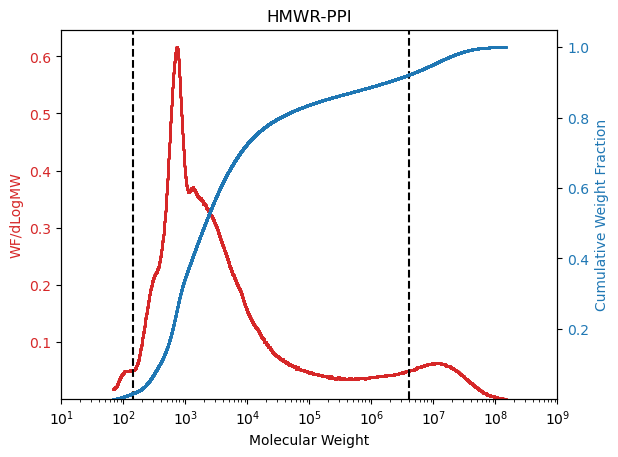

In [64]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPI")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_HMWR_PPI_dd_Mod),np.max(Data_HMWR_PPI_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_HMWR_PPI_cwf_Mod),np.max(Data_HMWR_PPI_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed",color="black")

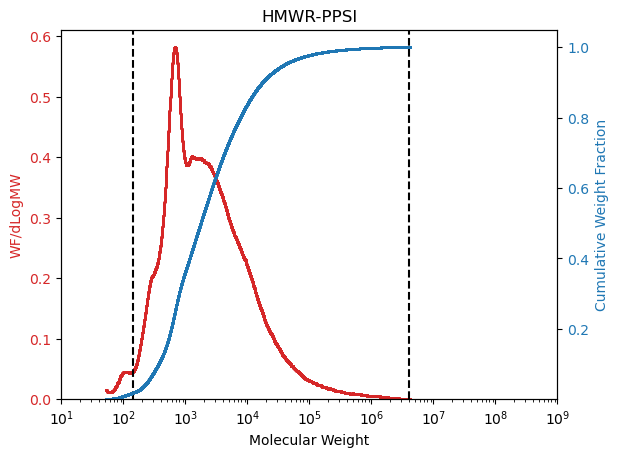

In [60]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPSI")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_HMWR_PPSI_dd_Mod),np.max(Data_HMWR_PPSI_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_HMWR_PPSI_cwf_Mod),np.max(Data_HMWR_PPSI_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed",color="black")

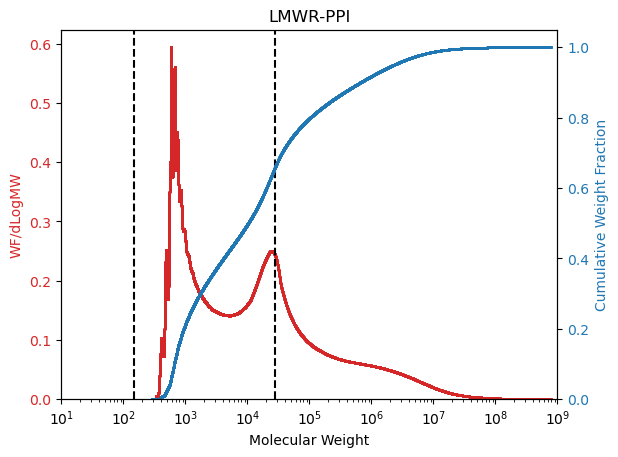

In [61]:
fig, ax1 = plt.subplots()
ax1.set_title("LMWR-PPI")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_LMWR_PPI_mp_Mod,Data_LMWR_PPI_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_LMWR_PPI_mp_Mod,Data_LMWR_PPI_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_LMWR_PPI_dd_Mod),np.max(Data_LMWR_PPI_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_LMWR_PPI_cwf_Mod),np.max(Data_LMWR_PPI_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.min(Data_PSL.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.max(Data_PSL.rv)]),linestyle="dashed",color="black")

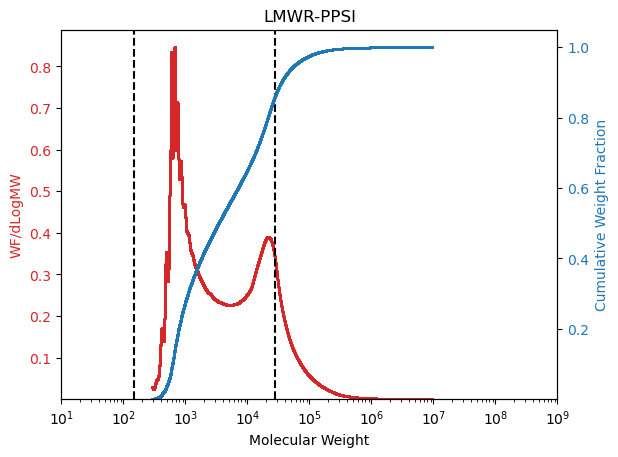

In [62]:
fig, ax1 = plt.subplots()
ax1.set_title("LMWR-PPSI")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_LMWR_PPSI_mp_Mod,Data_LMWR_PPSI_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_LMWR_PPSI_mp_Mod,Data_LMWR_PPSI_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_LMWR_PPSI_dd_Mod),np.max(Data_LMWR_PPSI_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_LMWR_PPSI_cwf_Mod),np.max(Data_LMWR_PPSI_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.min(Data_PSL.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.max(Data_PSL.rv)]),linestyle="dashed",color="black")

# Finding Average Molecular Weights

In [ ]:
def MolecularWeightFinder(RelativeIntensityData,RetentionVolumeData,MolecularMassData,IterativeSteps):
    MaximumRetentionVolume = np.max(RetentionVolumeData)
    MinimumRetentionVolume = np.min(RetentionVolumeData)
    RetentionVolumeRange = MaximumRetentionVolume-MinimumRetentionVolume
    VolumePerStep = RetentionVolumeRange/IterativeSteps

    IterativelyProducedAverages_ri = []
    IterativelyProducedAverages_mp = []
    CurrentVolume = MinimumRetentionVolume
    for step in range(IterativeSteps):
        if step+1 == IterativeSteps:
            LowerVolumeLimit = CurrentVolume
            UpperVolumeLimit = CurrentVolume+VolumePerStep

            LowerVolumeLimitIdx = 0
            for count,RetentionVolumeDatum in enumerate(RetentionVolumeData):
                if RetentionVolumeDatum > LowerVolumeLimit:
                    LowerVolumeLimitIdx = count
                    break

            UpperVolumeLimitIdx = len(RetentionVolumeData)-1

            VolumeIdxRange = np.linspace(LowerVolumeLimitIdx,UpperVolumeLimitIdx,(UpperVolumeLimitIdx-LowerVolumeLimitIdx)+1).astype('int').tolist()
            
            Filtered_ri = np.array(RelativeIntensityData)[VolumeIdxRange]
            Filtered_mp = np.array(MolecularMassData)[VolumeIdxRange]

            ri_avg = np.average(Filtered_ri)
            mp_avg = np.average(Filtered_mp)

            IterativelyProducedAverages_ri.append(ri_avg)
            IterativelyProducedAverages_mp.append(mp_avg)
            break
        else:
            LowerVolumeLimit = CurrentVolume
            UpperVolumeLimit = CurrentVolume+VolumePerStep

            LowerVolumeLimitIdx = 0
            UpperVolumeLimitIdx = 0

            for count,RetentionVolumeDatum in enumerate(RetentionVolumeData):
                if RetentionVolumeDatum > LowerVolumeLimit:
                    LowerVolumeLimitIdx = count
                    break
                
            for count,RetentionVolumeDatum in enumerate(RetentionVolumeData):
                if RetentionVolumeDatum > UpperVolumeLimit:
                    UpperVolumeLimitIdx = count
                    break

            VolumeIdxRange = np.linspace(LowerVolumeLimitIdx,UpperVolumeLimitIdx,(UpperVolumeLimitIdx-LowerVolumeLimitIdx)+1).astype('int').tolist()
            
            Filtered_ri = np.array(RelativeIntensityData)[VolumeIdxRange]
            Filtered_mp = np.array(MolecularMassData)[VolumeIdxRange]

            ri_avg = np.average(Filtered_ri)
            mp_avg = np.average(Filtered_mp)

            IterativelyProducedAverages_ri.append(ri_avg)
            IterativelyProducedAverages_mp.append(mp_avg)

            CurrentVolume = UpperVolumeLimit
            continue

    # Number Average Molecular Weight
    a = np.sum(IterativelyProducedAverages_ri)
    b = np.array(IterativelyProducedAverages_ri)
    c = np.array(IterativelyProducedAverages_mp)
    d = b/c
    e = np.sum(d)
    f = a/e

    # Weight Average Molecular Weight
    g = b*c
    h = np.sum(g)
    i = h/a

    # Dispersity
    j = i/f

    return f,i,j # number average, weight average, dispersity

In [43]:
IterativeSteps = 1000
HMWR_PPI_NumAveMolWei,HMWR_PPI_WeiAveMolWei,HMWR_PPI_Disp = MolecularWeightFinder(Data_HMWR_PPI_ri,Data_HMWR_PPI_rv,Data_HMWR_PPI_mp,IterativeSteps)
HMWR_PPSI_NumAveMolWei,HMWR_PPSI_WeiAveMolWei,HMWR_PPSI_Disp = MolecularWeightFinder(Data_HMWR_PPSI_ri,Data_HMWR_PPSI_rv,Data_HMWR_PPSI_mp,IterativeSteps)
LMWR_PPI_NumAveMolWei,LMWR_PPI_WeiAveMolWei,LMWR_PPI_Disp = MolecularWeightFinder(Data_LMWR_PPI_ri,Data_LMWR_PPI_rv,Data_LMWR_PPI_mp,IterativeSteps)
LMWR_PPSI_NumAveMolWei,LMWR_PPSI_WeiAveMolWei,LMWR_PPSI_Disp = MolecularWeightFinder(Data_LMWR_PPSI_ri,Data_LMWR_PPSI_rv,Data_LMWR_PPSI_mp,IterativeSteps)

In [44]:
print("Gel Permeation Chromatography")
print("=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-")
print("Two polystyrene samples of either high (HMWR) or low (LMWR) molecular weights used as standards.")
print("Two different samples have been trialled, one being a polymer of propylene glycol and itaconic acid (PPI) and the other also containing succinic acid (PPSI).")
print("Samples of PPI were run at 5 mg/ml whilst the PPSI samples were run at 10 mg/ml and the solvent was tetrahydrofuran.")
print("=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-")
print(f"Overview at {IterativeSteps} iterations across the retention volume handled:")
print()
print(f"\t\tNumber Average Mr\tWeight Average Mr\tDispersity")
print(f"HMWR-PPI:\t{round(HMWR_PPI_NumAveMolWei,2)}\t\t\t{round(HMWR_PPI_WeiAveMolWei,2)}\t\t{round(HMWR_PPI_Disp,2)}")
print(f"HMWR-PPSI:\t{round(HMWR_PPSI_NumAveMolWei,2)}\t\t\t{round(HMWR_PPSI_WeiAveMolWei,2)}\t\t{round(HMWR_PPSI_Disp,2)}")
print(f"LMWR-PPI:\t{round(LMWR_PPI_NumAveMolWei,2)}\t\t\t{round(LMWR_PPI_WeiAveMolWei,2)}\t\t{round(LMWR_PPI_Disp,2)}")
print(f"LMWR-PPSI:\t{round(LMWR_PPSI_NumAveMolWei,2)}\t\t\t{round(LMWR_PPSI_WeiAveMolWei,2)}\t\t{round(LMWR_PPSI_Disp,2)}")

Gel Permeation Chromatography
=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
Two polystyrene samples of either high (HMWR) or low (LMWR) molecular weights used as standards.
Two different samples have been trialled, one being a polymer of propylene glycol and itaconic acid (PPI) and the other also containing succinic acid (PPSI).
Samples of PPI were run at 5 mg/ml whilst the PPSI samples were run at 10 mg/ml and the solvent was tetrahydrofuran.
=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
Overview at 1000 iterations across the retention volume handled:

		Number Average Mr	Weight Average Mr	Dispersity
HMWR-PPI:	951.64			1559182.62		1638.42
HMWR-PPSI:	863.35			14734.83		17.07
LMWR-PPI:	2157.86			740986.09		343.39
LMWR-PPSI:	1634.02			17901.04		10.96


In [45]:
# 5 mg/ml
Mn_HMWR_PPI_Domino = np.average(np.array([643,682,688,688,665]))
Mw_HMWR_PPI_Domino = np.average(np.array([973084,992613,978482,965093,947092]))
Dis_HMWR_PPI_Domino = Mw_HMWR_PPI_Domino/Mn_HMWR_PPI_Domino
Mn_HMWR_PPSI_Domino = np.average(np.array([664,651,642,635,624]))
Mw_HMWR_PPSI_Domino = np.average(np.array([17598,16729,17446,15378,15965]))
Dis_HMWR_PPSI_Domino = Mw_HMWR_PPSI_Domino/Mn_HMWR_PPSI_Domino

# 10 mg/ml
Mn_LMWR_PPI_Domino = np.average(np.array([2163,1943,1976,2293,68627]))
Mw_LMWR_PPI_Domino = np.average(np.array([70017,62119,62969,69199,68627]))
Dis_LMWR_PPI_Domino = Mw_LMWR_PPI_Domino/Mn_LMWR_PPI_Domino
Mn_LMWR_PPSI_Domino = np.average(np.array([1688,1719,1714,1721,1691]))
Mw_LMWR_PPSI_Domino = np.average(np.array([8710,8467,8393,8452,8450]))
Dis_LMWR_PPSI_Domino = Mw_LMWR_PPSI_Domino/Mn_LMWR_PPSI_Domino

print(f"\t\tNumber Average Mr\tWeight Average Mr\tDispersity")
print(f"HMWR-PPI:\t{round(Mn_HMWR_PPI_Domino,2)}\t\t\t{round(Mw_HMWR_PPI_Domino,2)}\t\t{round(Dis_HMWR_PPI_Domino,2)}")
print(f"HMWR-PPSI:\t{round(Mn_HMWR_PPSI_Domino,2)}\t\t\t{round(Mw_HMWR_PPSI_Domino,2)}\t\t\t{round(Dis_HMWR_PPSI_Domino,2)}")
print(f"LMWR-PPI:\t{round(Mn_LMWR_PPI_Domino,2)}\t\t\t{round(Mw_LMWR_PPI_Domino,2)}\t\t\t{round(Dis_LMWR_PPI_Domino,2)}")
print(f"LMWR-PPSI:\t{round(Mn_LMWR_PPSI_Domino,2)}\t\t\t{round(Mw_LMWR_PPSI_Domino,2)}\t\t\t{round(Dis_LMWR_PPSI_Domino,2)}")

		Number Average Mr	Weight Average Mr	Dispersity
HMWR-PPI:	673.2			971272.8		1442.77
HMWR-PPSI:	643.2			16623.2			25.84
LMWR-PPI:	15400.4			66586.2			4.32
LMWR-PPSI:	1706.6			8494.4			4.98


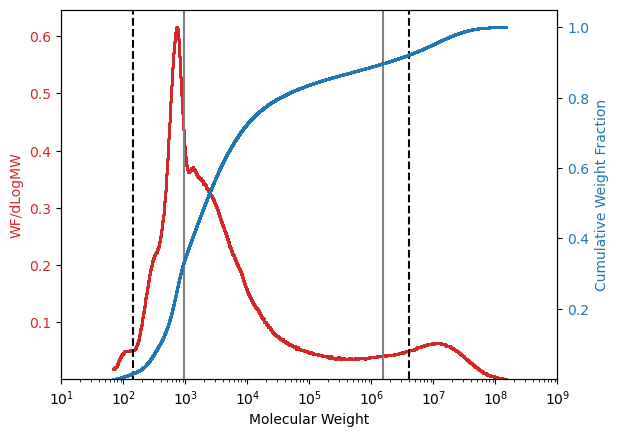

In [ ]:
fig, ax1 = plt.subplots()
# ax1.set_title("HMWR-PPI")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_HMWR_PPI_mp_Mod,Data_HMWR_PPI_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_HMWR_PPI_dd_Mod),np.max(Data_HMWR_PPI_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_HMWR_PPI_cwf_Mod),np.max(Data_HMWR_PPI_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed",color="black")

ax1.axvline(ymin=0,ymax=1,x=HMWR_PPI_NumAveMolWei,color="grey")
ax1.axvline(ymin=0,ymax=1,x=HMWR_PPI_WeiAveMolWei,color="grey")

# ax1.vlines(ymin=0,ymax=1,x=2400,color="green")

# plt.savefig(fname='HMWR-PPI.png',bbox_inches="tight",dpi=1000,format='png')
# plt.savefig(fname='CorrectionalMethod.pdf',bbox_inches="tight",dpi=1000,format='pdf')

In [ ]:
fig, ax1 = plt.subplots()
# ax1.set_title("HMWR-PPSI")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_HMWR_PPSI_dd_Mod),np.max(Data_HMWR_PPSI_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_HMWR_PPSI_cwf_Mod),np.max(Data_HMWR_PPSI_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed",color="black")

ax1.axvline(ymin=0,ymax=1,x=HMWR_PPSI_NumAveMolWei,color="grey")
ax1.axvline(ymin=0,ymax=1,x=HMWR_PPSI_WeiAveMolWei,color="grey")

plt.savefig(fname='HMWR-PPSI.png',bbox_inches="tight",dpi=1000,format='png')
# plt.savefig(fname='CorrectionalMethod.pdf',bbox_inches="tight",dpi=1000,format='pdf')

In [ ]:
fig, ax1 = plt.subplots()
# ax1.set_title("LMWR-PPI")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_LMWR_PPI_mp_Mod,Data_LMWR_PPI_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_LMWR_PPI_mp_Mod,Data_LMWR_PPI_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_LMWR_PPI_dd_Mod),np.max(Data_LMWR_PPI_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_LMWR_PPI_cwf_Mod),np.max(Data_LMWR_PPI_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.min(Data_PSL.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.max(Data_PSL.rv)]),linestyle="dashed",color="black")

ax1.axvline(ymin=0,ymax=1,x=LMWR_PPI_NumAveMolWei,color="grey")
ax1.axvline(ymin=0,ymax=1,x=LMWR_PPI_WeiAveMolWei,color="grey")

plt.savefig(fname='LMWR-PPI.png',bbox_inches="tight",dpi=1000,format='png')
# plt.savefig(fname='CorrectionalMethod.pdf',bbox_inches="tight",dpi=1000,format='pdf')

In [ ]:
fig, ax1 = plt.subplots()
ax1.set_title("LMWR-PPSI")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_LMWR_PPSI_mp_Mod,Data_LMWR_PPSI_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_LMWR_PPSI_mp_Mod,Data_LMWR_PPSI_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_LMWR_PPSI_dd_Mod),np.max(Data_LMWR_PPSI_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_LMWR_PPSI_cwf_Mod),np.max(Data_LMWR_PPSI_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.min(Data_PSL.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSL_rv_mp([np.max(Data_PSL.rv)]),linestyle="dashed",color="black")

ax1.axvline(ymin=0,ymax=1,x=LMWR_PPSI_NumAveMolWei,color="grey")
ax1.axvline(ymin=0,ymax=1,x=LMWR_PPSI_WeiAveMolWei,color="grey")

plt.savefig(fname='LMWR-PPSI.png',bbox_inches="tight",dpi=1000,format='png')
# plt.savefig(fname='CorrectionalMethod.pdf',bbox_inches="tight",dpi=1000,format='pdf')